In [11]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

runs_dir = Path("../results/runs")
runs = sorted(runs_dir.glob("lstm_mlp_*.json"))
if not runs:
    raise FileNotFoundError("No lstm_mlp_*.json in results/runs/. Run the training cell above first.")
latest = runs[-1]
print(f"Loading: {latest.name}")
with open(latest) as f:
    record = json.load(f)

print(f"  tag        = {record['tag']!r}")
print(f"  device     = {record['device']}")
print(f"  epochs     = {record['training']['epochs_run']}")
print(f"  best val   = {record['training']['best_val_loss']:.5f}")
print(f"  mean R²_OS = {record['metrics']['out_of_sample']['r2_oos_mean']:.4f}")

Loading: lstm_mlp_20260609T063539_4855840000.json
  tag        = 'lstm-mlp-baseline'
  device     = cuda
  epochs     = 50
  best val   = 3.44208
  mean R²_OS = 0.0006


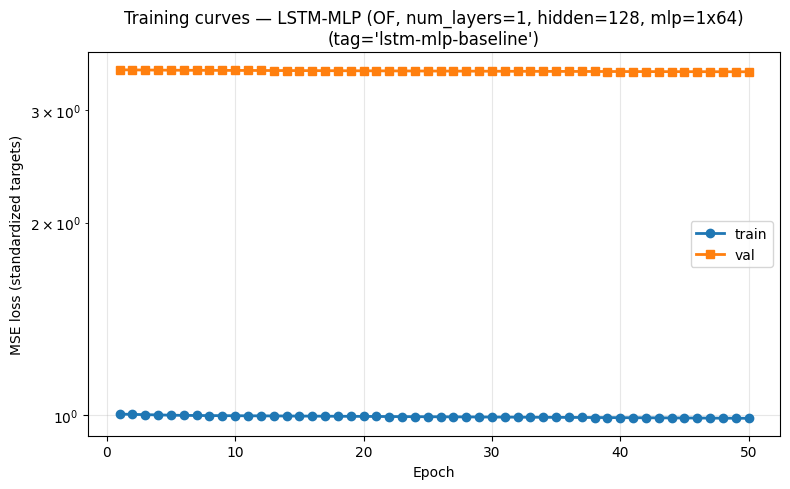

In [12]:
history = record["training"]["history"]
train_losses = history["train_loss"]
val_losses = history["val_loss"]
epochs = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_losses, marker="o", label="train", linewidth=2)
ax.plot(epochs, val_losses, marker="s", label="val", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss (standardized targets)")
ax.set_yscale("log")
ax.set_title(f"Training curves — {record['model']}\n(tag={record['tag']!r})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

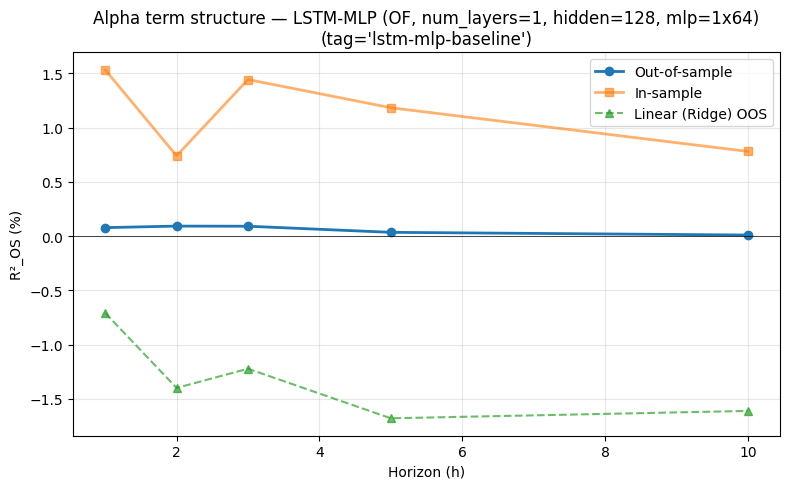

In [13]:
horizons = record["horizons"]
oos_r2 = record["metrics"]["out_of_sample"]["r2_oos"]
in_r2 = record["metrics"]["in_sample"]["r2_oos"]
oos_pct = [oos_r2[str(h)] * 100 for h in horizons]
in_pct  = [in_r2[str(h)]  * 100 for h in horizons]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(horizons, oos_pct, marker="o", label="Out-of-sample", linewidth=2)
ax.plot(horizons, in_pct,  marker="s", label="In-sample", linewidth=2, alpha=0.6)

bench = record["metrics"].get("linear_benchmark_oos")
if bench:
    bench_pct = [bench["r2_oos"][str(h)] * 100 for h in horizons]
    ax.plot(horizons, bench_pct, marker="^", linestyle="--",
            label="Linear (Ridge) OOS", alpha=0.7)

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Horizon (h)")
ax.set_ylabel("R²_OS (%)")
ax.set_title(f"Alpha term structure — {record['model']}\n(tag={record['tag']!r})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
!python ../scripts/analyze_lstm_baseline_experiments.py --prefix ls1-     # pick lr/stride


rank tag                        lr     wd  hid  nl  drop  strd  sd  ep  best_val   ftrain    oos_r2  oos_dir  oos_shrp    ins_r2    score
-----------------------------------------------------------------------------------------------------------------------------------------
   1 ls1-lr1e5-st10          1e-05  0e+00  128   1  0.00    10  42  60    3.5565   0.9841   +0.0004   0.6043   +0.4121   +0.0162   0.6583
   2 ls1-lr3e4-st10          3e-04  0e+00  128   1  0.00    10  42  15    3.5423   0.9089   -0.0003   0.5990   +0.4116   +0.0439   0.5846
   3 ls1-lr1e3-st10          1e-03  0e+00  128   1  0.00    10  42  12    3.5377   0.8454   -0.0010   0.5901   +0.4494   +0.0486   0.5254
   4 ls1-lr3e4-st25          3e-04  0e+00  128   1  0.00    25  42  19    3.4360   0.8663   -0.0003   0.5861   +0.2895   +0.0571   0.4327
   5 ls1-lr1e3-st25          1e-03  0e+00  128   1  0.00    25  42  12    3.4324   0.8146   -0.0015   0.5997   +0.3377   +0.0411   0.3841
   6 ls1-lr1e4-st25          1e-04